
# Cross‑Platform Coverage Analysis  
Using **indie.csv** and **notindie.csv**

This notebook analyzes platform coverage across **Steam**, **Epic**, and **IGDB** for both **indie** and **non‑indie** games.


In [1]:

import ast
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 200)

def parse_list(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else (x if isinstance(x, list) else [])
    except:
        return []


## Load Data

In [2]:
indie_path = '../data/gold/indie.csv'
notindie_path = '../data/gold/notindie.csv'
indie = pd.read_csv(indie_path)
notindie = pd.read_csv(notindie_path)

# Parse platform list
indie["platform_list"] = indie["platform"].apply(parse_list)
notindie["platform_list"] = notindie["platform"].apply(parse_list)

## Platform Presence Summary

In [3]:

def has_platform(df, col):
    return df[col].notna().astype(int)

# Presence flags
for df in [indie, notindie]:
    df["steam_flag"] = df["steam_ID"].notna().astype(int)
    df["epic_flag"] = df["epic_ID"].notna().astype(int)
    df["igdb_flag"] = df["igdb_ID"].notna().astype(int)

summary = pd.DataFrame({
    "Indie": [
        indie["steam_flag"].sum(),
        indie["epic_flag"].sum(),
        indie["igdb_flag"].sum()
    ],
    "Not Indie": [
        notindie["steam_flag"].sum(),
        notindie["epic_flag"].sum(),
        notindie["igdb_flag"].sum()
    ]
}, index=["Steam", "Epic", "IGDB"])

summary


,Indie,Not Indie
Steam,50946,19540
Epic,1727,4943
IGDB,80851,49277


## Platform Coverage Comparison

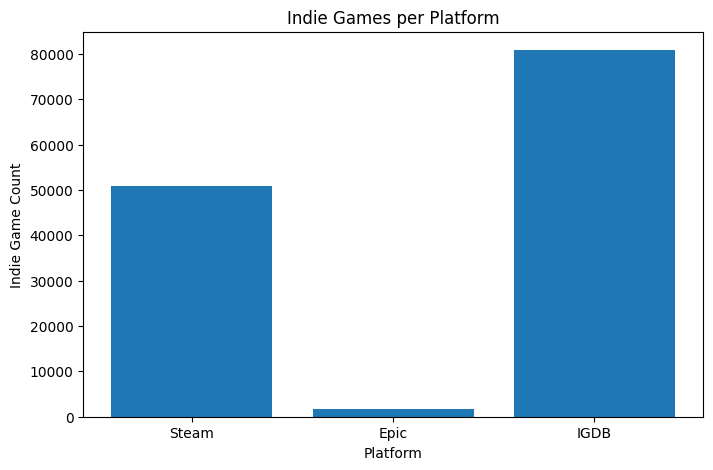

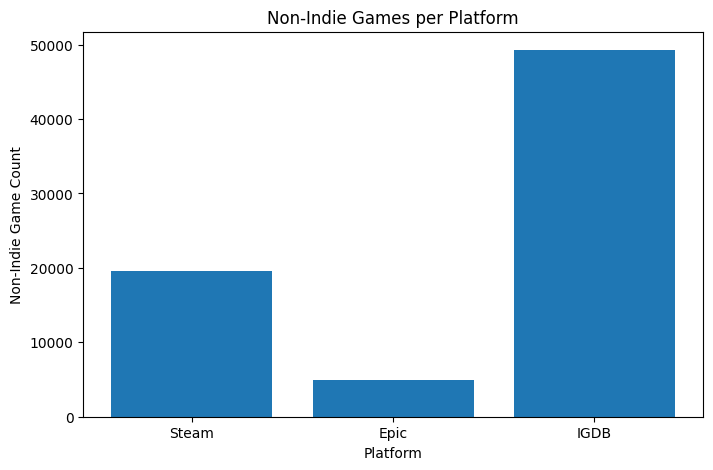

In [4]:

plt.figure(figsize=(8,5))
plt.bar(["Steam","Epic","IGDB"], summary["Indie"])
plt.xlabel("Platform")
plt.ylabel("Indie Game Count")
plt.title("Indie Games per Platform")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(["Steam","Epic","IGDB"], summary["Not Indie"])
plt.xlabel("Platform")
plt.ylabel("Non‑Indie Game Count")
plt.title("Non‑Indie Games per Platform")
plt.show()


## Cross‑Platform Combination Analysis

In [7]:
combo_labels = {
    "100": "Steam only",
    "010": "Epic only",
    "001": "IGDB only",
    "110": "Steam + Epic",
    "101": "Steam + IGDB",
    "011": "Epic + IGDB",
    "111": "Steam + Epic + IGDB",
    "000": "No Platform IDs"
}

In [5]:

def combo(df):
    return df["steam_flag"].astype(str) + df["epic_flag"].astype(str) + df["igdb_flag"].astype(str)

indie["combo"] = combo(indie)
notindie["combo"] = combo(notindie)

indie_combo_counts = indie["combo"].value_counts().sort_index()
not_combo_counts = notindie["combo"].value_counts().sort_index()

indie_combo_counts, not_combo_counts


(combo
 001    40970
 100    10925
 101    38294
 110      140
 111     1587
 Name: count, dtype: int64,
 combo
 001    35684
 010     2944
 011     1125
 100     6881
 101    11785
 110      191
 111      683
 Name: count, dtype: int64)

## Cross‑Platform Overlap Visualization

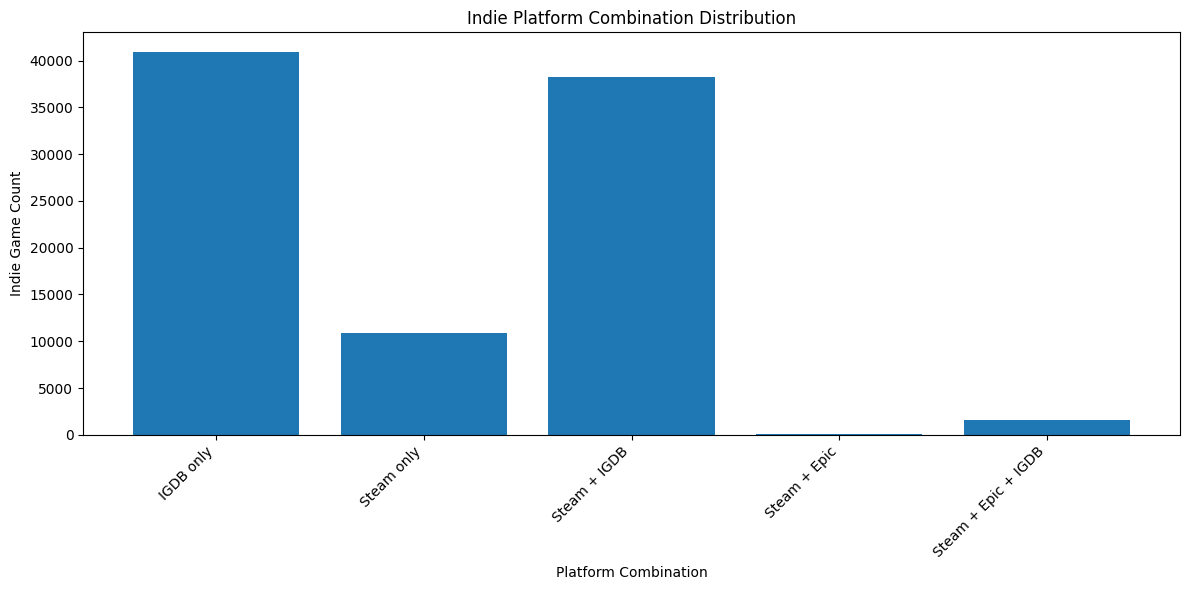

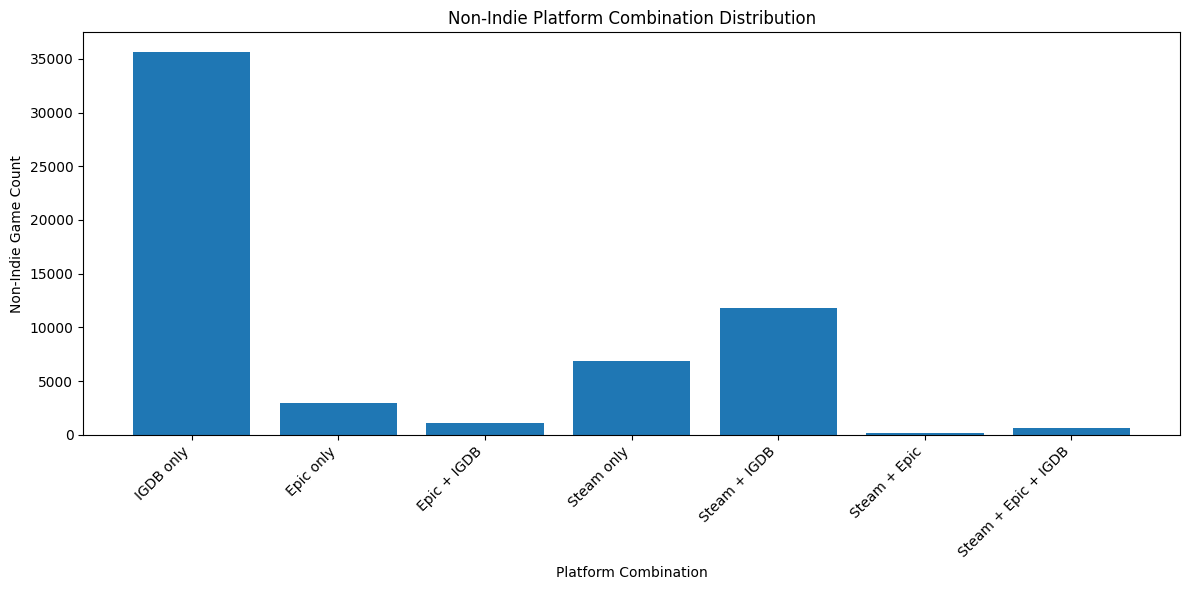

In [11]:
# Use the readable labels for indie combos
indie_combo_labels = [combo_labels.get(c, c) for c in indie_combo_counts.index]

plt.figure(figsize=(12,6))
plt.bar(indie_combo_labels, indie_combo_counts.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Platform Combination")
plt.ylabel("Indie Game Count")
plt.title("Indie Platform Combination Distribution")
plt.tight_layout()
plt.show()

# Same for non-indie
not_combo_labels = [combo_labels.get(c, c) for c in not_combo_counts.index]

plt.figure(figsize=(12,6))
plt.bar(not_combo_labels, not_combo_counts.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Platform Combination")
plt.ylabel("Non-Indie Game Count")
plt.title("Non-Indie Platform Combination Distribution")
plt.tight_layout()
plt.show()

## Multi‑Platform Rate

In [9]:

indie["platform_count"] = indie["platform_list"].apply(len)
notindie["platform_count"] = notindie["platform_list"].apply(len)

multiplatform = pd.DataFrame({
    "Indie": indie["platform_count"].value_counts().sort_index(),
    "Not Indie": notindie["platform_count"].value_counts().sort_index()
})

multiplatform


,Indie,Not Indie
platform_count,,
1,51895,45509
2,38434,13101
3,1587,683


## Multi‑Platform Distribution Plot

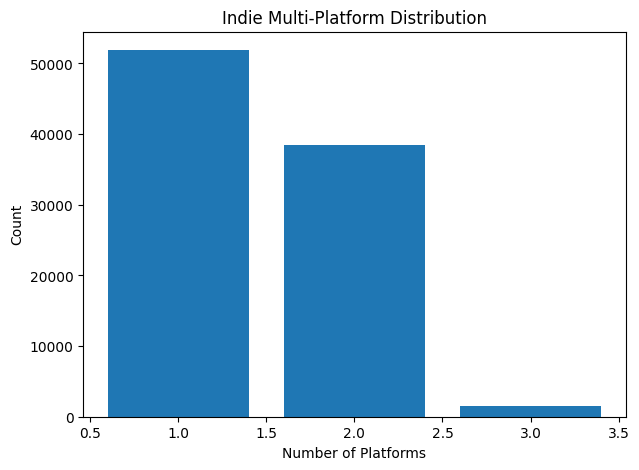

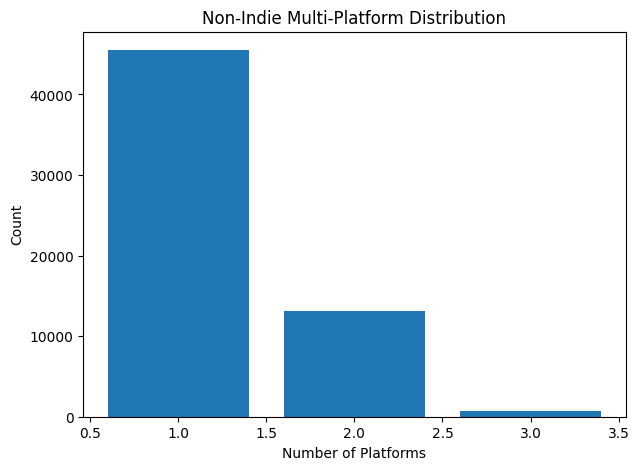

In [10]:

plt.figure(figsize=(7,5))
plt.bar(multiplatform.index, multiplatform["Indie"])
plt.xlabel("Number of Platforms")
plt.ylabel("Count")
plt.title("Indie Multi‑Platform Distribution")
plt.show()

plt.figure(figsize=(7,5))
plt.bar(multiplatform.index, multiplatform["Not Indie"])
plt.xlabel("Number of Platforms")
plt.ylabel("Count")
plt.title("Non‑Indie Multi‑Platform Distribution")
plt.show()
